**Введение**

**Вопрос 1: 5 примеров применения ML методов в жизни**

Пример ->	Польза

Распознавание лиц в смартфоне ->	Безопасность, удобство разблокировки устройства, автоматическая организация фото

Рекомендации товаров на Wildberries/Ozon ->	Увеличение продаж, персонализация, экономия времени покупателя

Спам-фильтр в почте -> Автоматическая очистка почты от нежелательных сообщений, защита от мошенников

Прогноз погоды ->	Планирование действий, предупреждение о стихийных бедствиях

Диагностика болезней по снимкам МРТ -> Раннее выявление заболеваний, помощь врачам, снижение ошибок

**Вопрос 2: Классификация задач из таблицы**

№ задачи из теории	Тип обучения	Подтип

1 (цена дома)	Supervised	Regression

2 (возврат кредита)	Supervised	Binary Classification

3 (время приёма лекарств)	Supervised	Regression

4 (выбор лекарства)	Supervised	Multiclass Classification

5 (сегменты для промо)	Unsupervised	Clustering

6 (дефекты на линии)	Supervised	Binary Classification

7 (размещение товаров)	Unsupervised	Association

8 (поиск сайтов)	Supervised	Ranking (особый тип - упорядочивание результатов по релевантности)

9 (сегментация клиентов)	Unsupervised	Clustering

10 (аномалии в трафике)	Unsupervised	Anomaly Detection

11 Распознавание лиц	Supervised	Multiclass Classification

12 Рекомендации товаров	Supervised / Unsupervised	Recommendation Systems (особый тип - можно решать как коллаборативную фильтрацию (unsupervised) или как предсказание рейтинга (supervised regression))

13 Спам-фильтр	Supervised	Binary Classification

14 Прогноз погоды	Supervised	Regression

15 Диагностика по МРТ	Supervised	Multiclass Classification

**Вопрос 3 Разница между Multiclass и Multilabel**

Multiclass (многоклассовая классификация) — каждый объект принадлежит ровно одному классу из нескольких возможных.
Пример: фрукт может быть яблоком, грушей или апельсином, но не двумя сразу.

Multilabel (многометочная классификация) — каждый объект может принадлежать нескольким классам одновременно.
Пример: фильм может быть одновременно "комедией", "боевиком" и "фантастикой".

**Вопрос 4: Задача с ценами на жильё — это регрессия или классификация?**

Задача предсказания цены дома — это регрессия, так как целевая переменная (цена) — непрерывное числовое значение.

Можно ли свести регрессию к классификации? **Да, можно**:

Дискретизировать цену: "дешёвая / средняя / дорогая"

Однако это приводит к потере информации и точности


In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

import scipy
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.stats import diagnostic

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_json('data/train.json')

In [3]:
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер данных: 49352 строк, 15 столбцов


In [4]:
print(df.columns.tolist())
print("\nЦелевая переменная (target): 'price'")

['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']

Целевая переменная (target): 'price'


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [6]:
print(df.describe())

         bathrooms      bedrooms      latitude    listing_id     longitude  \
count  49352.00000  49352.000000  49352.000000  4.935200e+04  49352.000000   
mean       1.21218      1.541640     40.741545  7.024055e+06    -73.955716   
std        0.50142      1.115018      0.638535  1.262746e+05      1.177912   
min        0.00000      0.000000      0.000000  6.811957e+06   -118.271000   
25%        1.00000      1.000000     40.728300  6.915888e+06    -73.991700   
50%        1.00000      1.000000     40.751800  7.021070e+06    -73.977900   
75%        1.00000      2.000000     40.774300  7.128733e+06    -73.954800   
max       10.00000      8.000000     44.883500  7.753784e+06      0.000000   

              price  
count  4.935200e+04  
mean   3.830174e+03  
std    2.206687e+04  
min    4.300000e+01  
25%    2.500000e+03  
50%    3.150000e+03  
75%    4.100000e+03  
max    4.490000e+06  


In [7]:
print(df[['bathrooms', 'bedrooms', 'price']].corr())

           bathrooms  bedrooms     price
bathrooms   1.000000  0.533446  0.069661
bedrooms    0.533446  1.000000  0.051788
price       0.069661  0.051788  1.000000


In [8]:
empty_cols = df.columns[df.isnull().all()].tolist()
empty_cols

[]

- в данных нет пропусков
- describe() описывает статистику по столбцам. Видим, например, по колонке bathrooms - в среднем 1.2 ванных комнаты, есть объявления без ванной, 75% объявлений имеют 1 ванную, есть аномалия — объявление с 10 ванными. По bedrooms - 1,54 в среднем, есть без спален, есть 8 спален. По price - средняя цена 3,830 $, огромное отклонение - 22,067 $, минимальная цена - 43 $, максимальная - 4,490,000 $, среднее (3,830) сильно отличается от медианы (3,150) — признак выбросов
- corr() строит корреляционную матрицу. Ванные и спальни слабо коррелируют с ценой (0.07 и 0.05). Количество ванных и спален почти не влияет на цену в рамках этого датасета. Возможно выбросы размывают корреляцию, влияние других факторов сильнее, наличие шума. bathrooms × bedrooms = 0.53 — умеренная положительная связь - логично, что в квартирах с большим числом спален обычно больше ванных комнат.
- Нет полностью пустых столбцов.

In [9]:
df_selected = df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
print(f"Новый датафрейм: {df_selected.shape}")
df_selected.head()

Новый датафрейм: (49352, 4)


,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


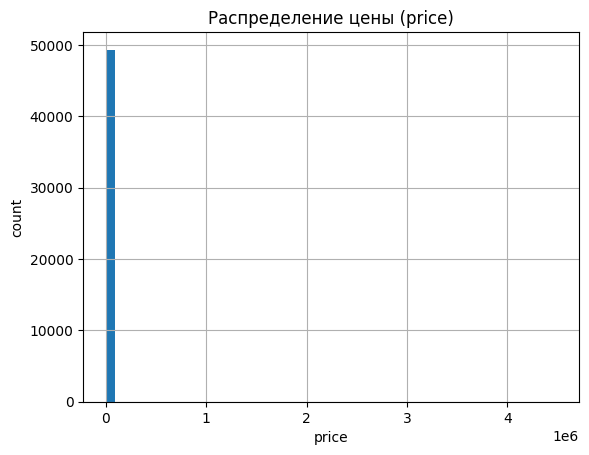

In [10]:
plt.figure()
df_selected['price'].dropna().hist(bins=50)
plt.title('Распределение цены (price)')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

Гистограмма неинформативна. 99% данных попало в один диапазон. Необходимо удалить выбросы.

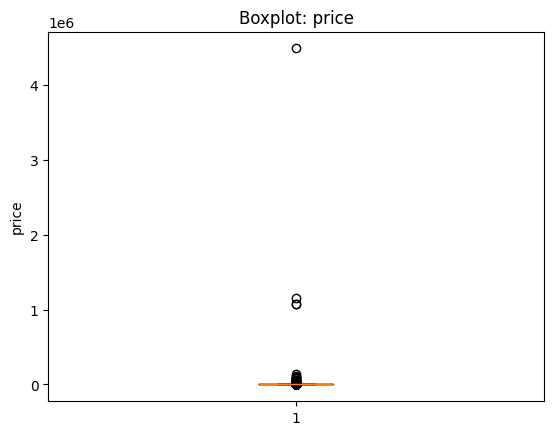

In [11]:
plt.figure()
plt.boxplot(df_selected['price'].dropna(), vert=True)
plt.title('Boxplot: price')
plt.ylabel('price')
plt.show()

Усы отсутствуют (раздавлены масштабом), ящик сжат (большое кол-во значений в узком диапазоне), Выбросы будут мешать обучению моделей машинного обучения, которые могут "запоминать" эти аномалии вместо выявления общих закономерностей.

In [12]:
# Удаление выбросов (за пределами 1 и 99 перцентилей)
lower_bound = df_selected['price'].quantile(0.01)
upper_bound = df_selected['price'].quantile(0.99)

print(f"1-й перцентиль: {lower_bound}")
print(f"99-й перцентиль: {upper_bound}")

df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

print(f"Было строк: {len(df_selected)}")
print(f"Стало строк: {len(df_cleaned)}")
print(f"Удалено выбросов: {len(df_selected) - len(df_cleaned)}")

1-й перцентиль: 1475.0
99-й перцентиль: 13000.0
Было строк: 49352
Стало строк: 48379
Удалено выбросов: 973


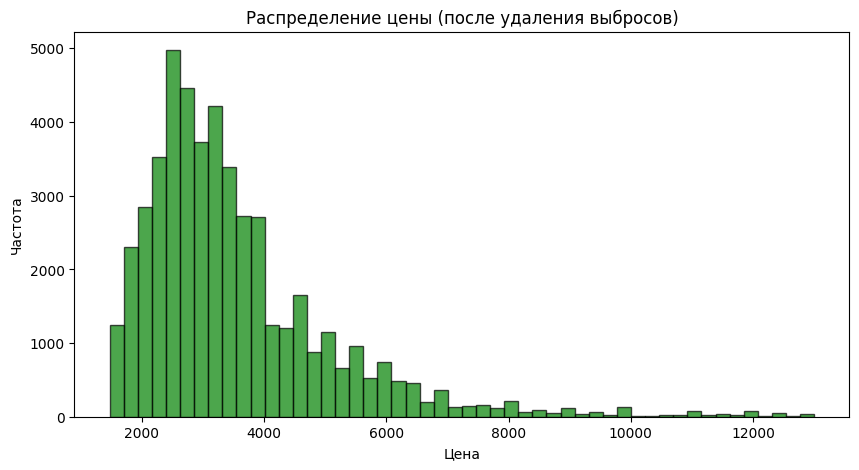

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df_cleaned['price'], bins=50, edgecolor='black', alpha=0.7, color='green')
plt.title('Распределение цены (после удаления выбросов)')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

После очистки распределение стало информативным:
Отчётливо виден пик в районе $2500-$3500

Удаление выбросов по перцентилям - эффективный метод первичной очистки,
позволяющий улучшить визуализацию и подготовить данные для построения моделей.

In [21]:
print(f"Тип колонки: {df_cleaned['interest_level'].dtype}")
print(df_cleaned['interest_level'].value_counts())

Тип колонки: object
interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64


In [24]:
encoding_map = {'low': 0, 'medium': 1, 'high': 2}
df_cleaned['interest_level_encoded'] = df_cleaned['interest_level'].map(encoding_map)

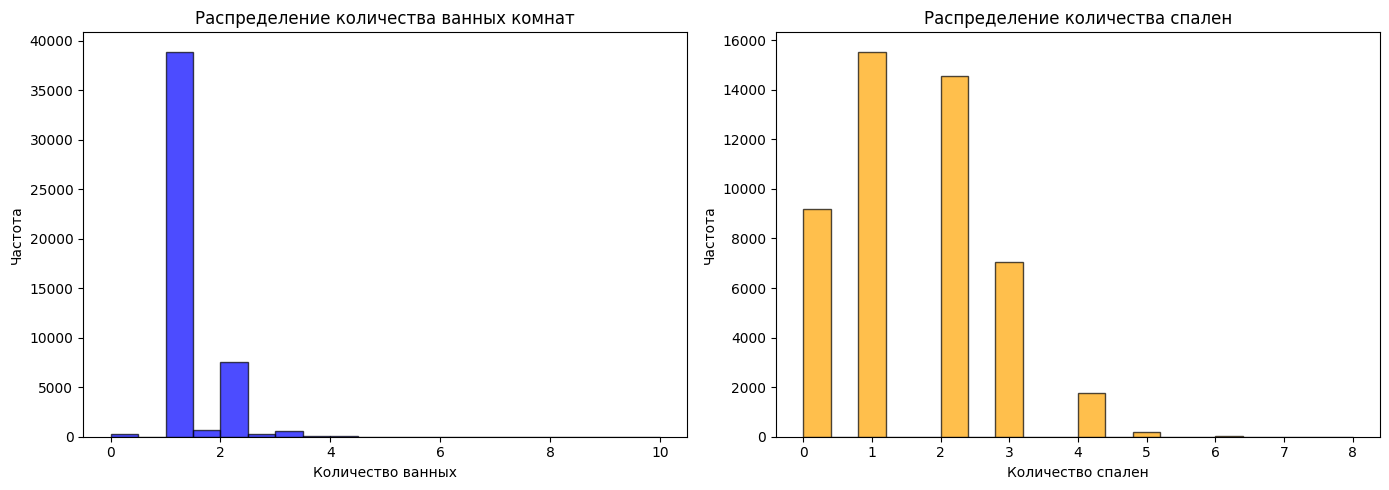

Проверка на выбросы в признаках:
  bathrooms: 9451 выбросов (19.54%)
  bedrooms: 2031 выбросов (4.20%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_cleaned['bathrooms'], bins=20, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_title('Распределение количества ванных комнат')
axes[0].set_xlabel('Количество ванных')
axes[0].set_ylabel('Частота')

axes[1].hist(df_cleaned['bedrooms'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Распределение количества спален')
axes[1].set_xlabel('Количество спален')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("Проверка на выбросы в признаках:")
for col in ['bathrooms', 'bedrooms']:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_cleaned[(df_cleaned[col] < Q1 - 1.5*IQR) | (df_cleaned[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} выбросов ({len(outliers)/len(df_cleaned)*100:.2f}%)")

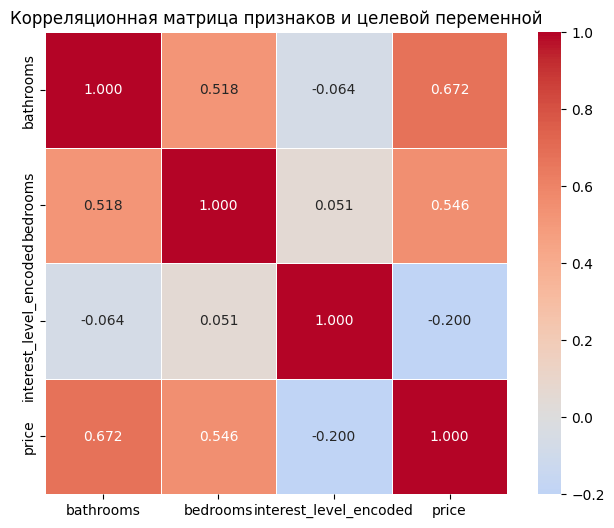


Корреляция с ценой (price):
  bathrooms: 0.6719
  bedrooms: 0.5459
  interest_level_encoded: -0.2001


In [17]:
features_for_corr = ['bathrooms', 'bedrooms', 'interest_level_encoded', 'price']
corr_matrix = df_cleaned[features_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Корреляционная матрица признаков и целевой переменной')
plt.show()

print("\nКорреляция с ценой (price):")
for col in ['bathrooms', 'bedrooms', 'interest_level_encoded']:
    print(f"  {col}: {corr_matrix.loc[col, 'price']:.4f}")

- Количество ванных комнат имеет наиболее сильную связь с ценой
- Количество спален также значимо коррелирует с ценой
- Уровень интереса показывает слабую отрицательную связь. То есть дорогие квартиры получают чуть меньше просмотров, однако вклад interest_level в предсказание минимален.

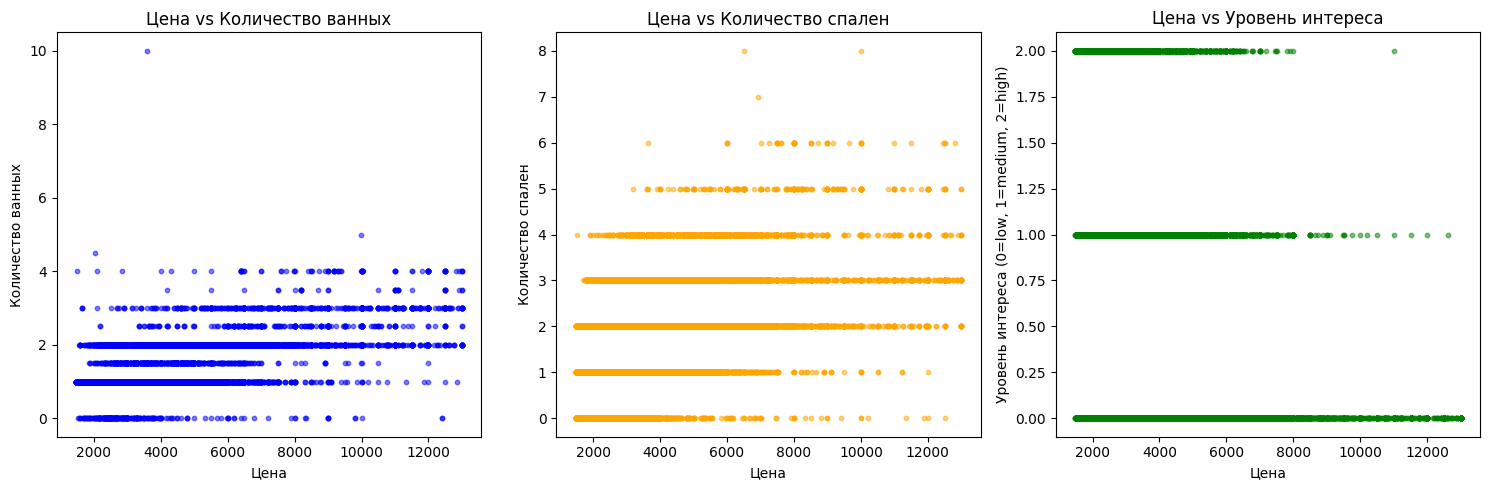

In [18]:
# Scatter plots для визуализации корреляции
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scatter_kwargs = {'alpha': 0.5, 's': 10}

axes[0].scatter(df_cleaned['price'], df_cleaned['bathrooms'], **scatter_kwargs, color='blue')
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Количество ванных')
axes[0].set_title('Цена vs Количество ванных')

axes[1].scatter(df_cleaned['price'], df_cleaned['bedrooms'], **scatter_kwargs, color='orange')
axes[1].set_xlabel('Цена')
axes[1].set_ylabel('Количество спален')
axes[1].set_title('Цена vs Количество спален')

axes[2].scatter(df_cleaned['price'], df_cleaned['interest_level_encoded'], **scatter_kwargs, color='green')
axes[2].set_xlabel('Цена')
axes[2].set_ylabel('Уровень интереса (0=low, 1=medium, 2=high)')
axes[2].set_title('Цена vs Уровень интереса')

plt.tight_layout()
plt.show()

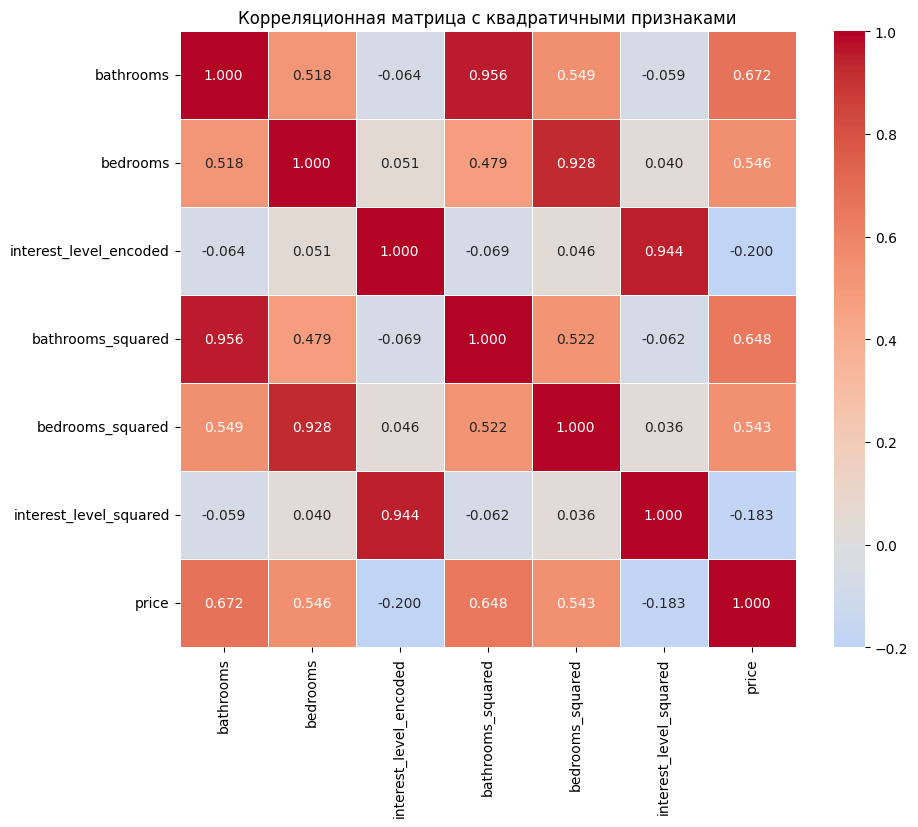


Корреляция квадратичных признаков с ценой:
  bathrooms_squared: 0.6485
  bedrooms_squared: 0.5434
  interest_level_squared: -0.1827


In [25]:
df_cleaned['bathrooms_squared'] = df_cleaned['bathrooms'] ** 2
df_cleaned['bedrooms_squared'] = df_cleaned['bedrooms'] ** 2
df_cleaned['interest_level_squared'] = df_cleaned['interest_level_encoded'] ** 2

new_features = ['bathrooms', 'bedrooms', 'interest_level_encoded',
                'bathrooms_squared', 'bedrooms_squared', 'interest_level_squared', 'price']

new_corr = df_cleaned[new_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(new_corr, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Корреляционная матрица с квадратичными признаками')
plt.show()

print("\nКорреляция квадратичных признаков с ценой:")
for col in ['bathrooms_squared', 'bedrooms_squared', 'interest_level_squared']:
    print(f"  {col}: {new_corr.loc[col, 'price']:.4f}")

Практически нет разницы в сравнении с базовыми

In [27]:
X = df_cleaned[['bathrooms', 'bedrooms']]
y = df_cleaned['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"\nПосле PolynomialFeatures:")
print(f"  Обучающая выборка: {X_train_poly.shape}")
print(f"  Тестовая выборка: {X_test_poly.shape}")
print(f"  Количество признаков: {X_train_poly.shape[1]}")

Размер обучающей выборки: (38703, 2)
Размер тестовой выборки: (9676, 2)

После PolynomialFeatures:
  Обучающая выборка: (38703, 65)
  Тестовая выборка: (9676, 65)
  Количество признаков: 65


In [28]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [33]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

y_train_pred_lr = lr.predict(X_train_poly)
y_test_pred_lr = lr.predict(X_test_poly)

mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

result_MAE = pd.concat([result_MAE, pd.DataFrame([{
    'model': 'linear_regression',
    'train': mae_train_lr,
    'test': mae_test_lr
}])], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{
    'model': 'linear_regression',
    'train': rmse_train_lr,
    'test': rmse_test_lr
}])], ignore_index=True)

print("Линейная регрессия обучена")
print(f"  MAE train: {mae_train_lr:.2f}, test: {mae_test_lr:.2f}")
print(f"  RMSE train: {rmse_train_lr:.2f}, test: {rmse_test_lr:.2f}")

Линейная регрессия обучена
  MAE train: 755.35, test: 760.74
  RMSE train: 1075.25, test: 1100.03


In [34]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_poly, y_train)

y_train_pred_dt = dt.predict(X_train_poly)
y_test_pred_dt = dt.predict(X_test_poly)

mae_train_dt = mean_absolute_error(y_train, y_train_pred_dt)
mae_test_dt = mean_absolute_error(y_test, y_test_pred_dt)
rmse_train_dt = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
rmse_test_dt = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

result_MAE = pd.concat([result_MAE, pd.DataFrame([{
    'model': 'decision_tree',
    'train': mae_train_dt,
    'test': mae_test_dt
}])], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{
    'model': 'decision_tree',
    'train': rmse_train_dt,
    'test': rmse_test_dt
}])], ignore_index=True)

print("Дерево решений обучено")
print(f"  MAE train: {mae_train_dt:.2f}, test: {mae_test_dt:.2f}")
print(f"  RMSE train: {rmse_train_dt:.2f}, test: {rmse_test_dt:.2f}")

Дерево решений обучено
  MAE train: 755.35, test: 759.30
  RMSE train: 1075.21, test: 1088.55


In [35]:
train_mean = y_train.mean()
train_median = y_train.median()

y_train_pred_mean = np.full_like(y_train, train_mean)
y_test_pred_mean = np.full_like(y_test, train_mean)

y_train_pred_median = np.full_like(y_train, train_median)
y_test_pred_median = np.full_like(y_test, train_median)

mae_train_mean = mean_absolute_error(y_train, y_train_pred_mean)
mae_test_mean = mean_absolute_error(y_test, y_test_pred_mean)
rmse_train_mean = np.sqrt(mean_squared_error(y_train, y_train_pred_mean))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, y_test_pred_mean))

mae_train_median = mean_absolute_error(y_train, y_train_pred_median)
mae_test_median = mean_absolute_error(y_test, y_test_pred_median)
rmse_train_median = np.sqrt(mean_squared_error(y_train, y_train_pred_median))
rmse_test_median = np.sqrt(mean_squared_error(y_test, y_test_pred_median))

result_MAE = pd.concat([result_MAE,
    pd.DataFrame([{'model': 'native_mean', 'train': mae_train_mean, 'test': mae_test_mean},
                  {'model': 'native_median', 'train': mae_train_median, 'test': mae_test_median}])
], ignore_index=True)

result_RMSE = pd.concat([result_RMSE,
    pd.DataFrame([{'model': 'native_mean', 'train': rmse_train_mean, 'test': rmse_test_mean},
                  {'model': 'native_median', 'train': rmse_train_median, 'test': rmse_test_median}])
], ignore_index=True)

print("Базовые модели обучены")
print(f"  Среднее значение цены на train: {train_mean:.2f}")
print(f"  Медиана цены на train: {train_median:.2f}")

Базовые модели обучены
  Среднее значение цены на train: 3537.26
  Медиана цены на train: 3150.00


In [37]:
print('MAE:')
display(result_MAE.sort_values(by='test').reset_index(drop=True))

print('RMSE:')
display(result_RMSE.sort_values(by='test').reset_index(drop=True))

best_mae_model = result_MAE.sort_values(by='test', ascending=True).iloc[0]['model']
best_rmse_model = result_RMSE.sort_values(by='test', ascending=True).iloc[0]['model']
print(f'Лучшая по MAE (test): {best_mae_model}')
print(f'Лучшая по RMSE (test): {best_rmse_model}')

MAE:


,model,train,test
0,decision_tree,755.352697,759.296083
1,linear_regression,755.345491,760.735792
2,linear_regression,755.345491,760.735792
3,linear_regression,755.345491,760.735792
4,linear_regression,755.345491,760.735792
5,native_median,1084.589257,1092.695329
6,native_mean,1137.691109,1143.009095


RMSE:


,model,train,test
0,decision_tree,1075.206434,1088.547480
1,linear_regression,1075.252157,1100.028648
2,linear_regression,1075.252157,1100.028648
3,linear_regression,1075.252157,1100.028648
4,linear_regression,1075.252157,1100.028648
5,native_mean,1599.229473,1591.304016
6,native_median,1645.449541,1639.375180


Лучшая по MAE (test): decision_tree
Лучшая по RMSE (test): decision_tree


- Дерево незначительно лучше линейной регрессии по обоим метрикам
- Decision Tree и Linear Regression предсказывают цену с ошибкой ~$760. Базовые модели (среднее/медиана) ошибаются на ~$1090-1140. ML модели на 30% точнее базовых!
- На реальных данных Decision Tree улавливает нелинейности, Linear Regression предполагает линейную связь через весовые коэффициенты